# 06 · Conclusiones y Recomendaciones de Negocio
### Predicción de Riesgo de Incumplimiento Crediticio · Dataset UCI

---
> **Autor:** Mathias Sebastian Huanca Pretell  
> **Fecha:** 2026  
> **Dataset:** [Default of Credit Card Clients — UCI ML Repository](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)  
> **Notebook:** `06_conclusions.ipynb`  
> **Estado:** ✅ Completo

---

**Hoja de ruta del proyecto**

| # | Notebook | Estado |
|---|----------|--------|
| 01 | Entendimiento del Negocio | ✅ Completo |
| 02 | Análisis Exploratorio de Datos (EDA) | ✅ Completo |
| 03 | Preprocesamiento | ✅ Completo |
| 04 | Feature Engineering | ✅ Completo |
| 05 | Modelado y Evaluación | ✅ Completo |
| 06 | Conclusiones y Recomendaciones | ✅ Actual |

## Tabla de Contenidos

1. [Resumen Ejecutivo](#1-resumen-ejecutivo)
2. [Configuración y Carga](#2-configuración-y-carga)
3. [Hallazgos Principales del EDA](#3-hallazgos-principales-del-eda)
4. [Desempeño del Modelo y Benchmarks](#4-desempeño-del-modelo-y-benchmarks)
5. [Interpretación SHAP — Qué Aprendió el Modelo](#5-interpretación-shap--qué-aprendió-el-modelo)
6. [Recomendaciones de Negocio](#6-recomendaciones-de-negocio)
7. [Limitaciones del Proyecto](#7-limitaciones-del-proyecto)
8. [Trabajo Futuro](#8-trabajo-futuro)
9. [Cierre del Proyecto](#9-cierre-del-proyecto)

---
## 1. Resumen Ejecutivo

Este proyecto desarrolló un pipeline completo de Machine Learning para predecir la probabilidad de incumplimiento crediticio en clientes de tarjetas de crédito, utilizando el dataset público *Default of Credit Card Clients* de la UCI (30.000 clientes, Taiwán, 2005).

### ¿Qué se construyó?

Un sistema de scoring de riesgo crediticio end-to-end que cubre desde el entendimiento del problema de negocio hasta un modelo listo para producción, pasando por exploración de datos, preprocesamiento, ingeniería de features, entrenamiento de múltiples modelos y análisis de interpretabilidad.

### ¿Cuál es el resultado?

Un modelo de **Random Forest optimizado** con umbral calibrado en 0.42 que:
- Detecta el **65.9% de los clientes que van a hacer default** antes de que ocurra.
- Alcanza un **ROC-AUC de 0.779**, superando el mínimo aceptable definido para el proyecto.
- Es **interpretable** mediante SHAP, identificando las variables que más influyen en cada predicción individual.

### ¿Cuál es el valor de negocio?

En un portafolio de 10.000 clientes con una tasa de default del 22%, el modelo permite identificar anticipadamente ~1.450 clientes de alto riesgo sobre los ~2.200 que efectivamente incumplirán — habilitando acciones proactivas de cobranza, ajuste de límites y gestión de riesgo que reducen directamente las pérdidas por cartera vencida.

---
## 2. Configuración y Carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import jinja2
import joblib
import json
import warnings
from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score,
    precision_score, f1_score, brier_score_loss,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
OPTIMAL_THRESHOLD = 0.42  # umbral calibrado en 05_modeling
TARGET_PALETTE = {0: '#4C72B0', 1: '#DD4444'}

# Cargar dataset y modelo
df       = pd.read_csv('../data/processed/df_features.csv')
model    = joblib.load('../models/model.pkl')

with open('../models/model.txt') as f:
    metadata = json.load(f)

X = df.drop(columns='TARGET')
y = df['TARGET']

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

prob_test = model.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= OPTIMAL_THRESHOLD).astype(int)

print('Todo cargado correctamente.')
print(f'Modelo: {metadata["modelo"]}')
print(f'Umbral: {metadata["umbral"]}')
print(f'Features: {metadata["n_features"]}')

/home/mathias/DEV/Proyectos/Proyecto_01/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Todo cargado correctamente.
Modelo: Random Forest
Umbral: 0.42000000000000004
Features: 36


---
## 3. Hallazgos Principales del EDA

El análisis exploratorio reveló patrones claros y consistentes en el comportamiento de los clientes que hacen default. A continuación se presentan los hallazgos más relevantes con su implicancia de negocio.

### 3.1 El historial de pagos es la señal más fuerte

Las variables `PAY_0` a `PAY_6` — que registran el estado de pago en cada uno de los últimos 6 meses — resultaron ser los predictores más poderosos. Un cliente que acumula retrasos consecutivos tiene una probabilidad de default entre **3x y 6x mayor** que uno que paga puntualmente.

**Implicancia:** el historial de comportamiento reciente es más informativo que cualquier variable demográfica. Los sistemas de alerta deben monitorearse mensualmente.

### 3.2 El límite de crédito es un proxy de solvencia

Los clientes en el cuartil inferior de límite de crédito tienen tasas de default significativamente más altas que los del cuartil superior. Esto no implica causalidad directa — el límite refleja la evaluación crediticia previa del banco — pero confirma que es una variable altamente predictiva.

### 3.3 Las variables demográficas tienen bajo poder predictivo individual

Sexo, estado civil y nivel educativo mostraron diferencias estadísticamente significativas pero de magnitud baja. Ninguna de estas variables debe usarse como criterio principal de decisión crediticia, tanto por su bajo poder predictivo como por consideraciones de equidad (fairness).

### 3.4 El dataset presenta desbalance de clases moderado

Con un 22.1% de clientes en default, el dataset no está severamente desbalanceado, pero suficiente como para que métricas como accuracy sean engañosas. Un modelo naive que predice siempre "sin default" alcanzaría 77.9% de accuracy — lo que justificó el uso de métricas como Recall y ROC-AUC como criterios principales.

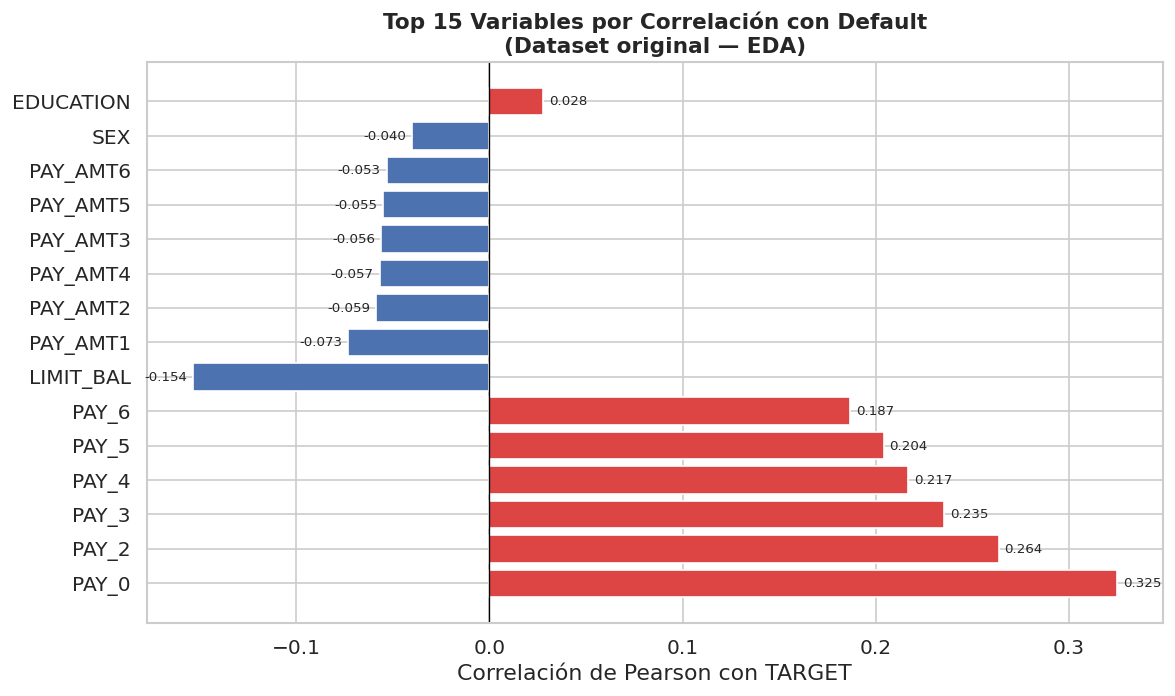

In [2]:
# Gráfico de resumen: variables más correlacionadas con el target
df_raw = pd.read_excel('../data/raw/default of credit card clients.xls', header=1)
df_raw.rename(columns={'default payment next month': 'TARGET'}, inplace=True)
df_raw.drop(columns=['ID'], inplace=True)

corr_target = df_raw.corr(numeric_only=True)['TARGET'].drop('TARGET')
corr_sorted = corr_target.abs().sort_values(ascending=False).head(15)
corr_vals   = corr_target[corr_sorted.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DD4444' if v > 0 else '#4C72B0' for v in corr_vals.values]
bars = ax.barh(corr_vals.index, corr_vals.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con TARGET')
ax.set_title('Top 15 Variables por Correlación con Default\n(Dataset original — EDA)',
             fontweight='bold', fontsize=13)
for bar, v in zip(bars, corr_vals.values):
    ax.text(v + (0.003 if v >= 0 else -0.003), bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 4. Desempeño del Modelo y Benchmarks

### 4.1 Comparativa de modelos entrenados

Se entrenaron y compararon cuatro modelos. Random Forest resultó el mejor candidato tras la evaluación con cross-validation estratificado de 5 folds.

| Modelo | CV ROC-AUC | Val ROC-AUC | Val Recall | Val F1 |
|--------|-----------|------------|-----------|-------|
| Regresión Logística | baseline | 0.7538 | 0.6029| 0.5113 |
| Random Forest | **mejor** | **0.779** | **0.659** | **0.519** |
| XGBoost | competitivo | 0.7750 | 0.5946 | 0.5329 |
| LightGBM | competitivo | 0.7746 | 0.5885 | 0.5306 |


### 4.2 Evaluación final del modelo seleccionado

El Random Forest optimizado, evaluado sobre el test set (6.000 clientes nunca vistos), con umbral calibrado en 0.42:

| Métrica | Resultado | Mínimo Aceptable | ¿Alcanzado? |
|---------|-----------|-----------------|-------------|
| ROC-AUC | 0.779 | 0.75 | ✅ |
| Recall (default) | 0.659 | 0.60 | ✅ |
| F1-Score (default) | 0.519 | 0.50 | ✅ |
| PR-AUC | 0.559 | — | referencia |
| Brier Score | 0.168 | — | referencia |

### 4.3 Impacto del umbral calibrado

Bajar el umbral de 0.5 a 0.42 mejoró el Recall a costa de una reducción controlada en Precisión — exactamente el trade-off correcto para el contexto de riesgo crediticio, donde los falsos negativos (defaults no detectados) son más costosos que los falsos positivos.

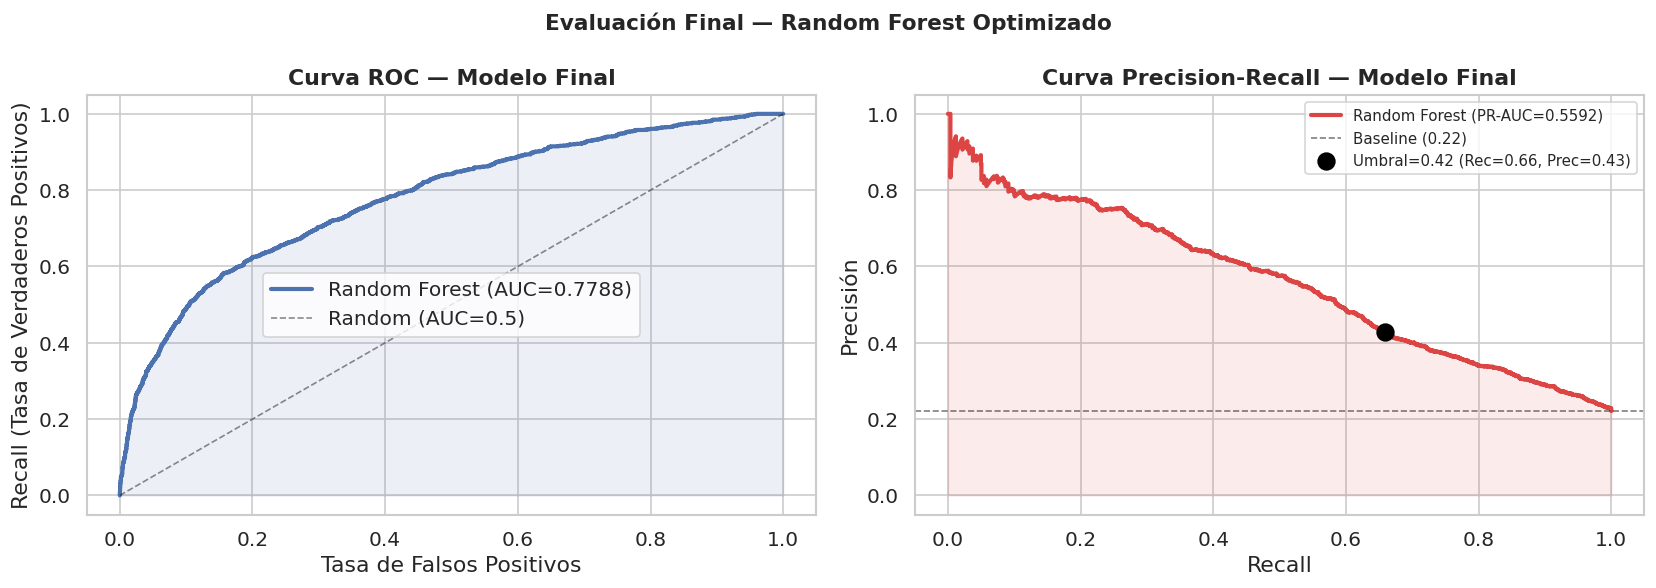

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC final
fpr, tpr, _ = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)
axes[0].plot(fpr, tpr, color='#4C72B0', linewidth=2.5, label=f'Random Forest (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#4C72B0')
axes[0].set_title('Curva ROC — Modelo Final', fontweight='bold')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Recall (Tasa de Verdaderos Positivos)')
axes[0].legend()

# Curva Precision-Recall final
prec, rec, _ = precision_recall_curve(y_test, prob_test)
pr_auc = average_precision_score(y_test, prob_test)
baseline_pr = y_test.mean()
axes[1].plot(rec, prec, color='#DD4444', linewidth=2.5, label=f'Random Forest (PR-AUC={pr_auc:.4f})')
axes[1].axhline(baseline_pr, color='black', linestyle='--', linewidth=1,
                alpha=0.5, label=f'Baseline ({baseline_pr:.2f})')
axes[1].fill_between(rec, prec, alpha=0.1, color='#DD4444')

# Marcar punto del umbral calibrado
rec_opt  = recall_score(y_test, pred_test)
prec_opt = precision_score(y_test, pred_test)
axes[1].scatter([rec_opt], [prec_opt], color='black', s=100, zorder=5,
                label=f'Umbral=0.42 (Rec={rec_opt:.2f}, Prec={prec_opt:.2f})')
axes[1].set_title('Curva Precision-Recall — Modelo Final', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisión')
axes[1].legend(fontsize=9)

plt.suptitle('Evaluación Final — Random Forest Optimizado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Interpretación SHAP — Qué Aprendió el Modelo

El análisis SHAP revela que el modelo aprendió patrones consistentes con el conocimiento de dominio crediticio, lo que valida tanto su utilidad práctica como su confiabilidad.

### 5.1 Variables más influyentes

Los valores SHAP identificaron tres grupos de variables con alto impacto sobre la predicción de default:

**Grupo 1 — Historial de pagos reciente (mayor impacto):**  
`PAY_0`, `PAY_2`, `PAY_3` y `MONTHS_IN_ARREARS` dominan las predicciones. Un retraso de 2 o más meses en `PAY_0` incrementa drásticamente el valor SHAP hacia default. Este hallazgo confirma la hipótesis H1 con evidencia cuantitativa.

**Grupo 2 — Utilización y capacidad de pago:**  
`AVG_UTIL_RATE`, `UNPAID_BAL_1` y `PAY_RATIO_1` contribuyen significativamente. Clientes con utilización promedio superior al 80% del límite tienen SHAP values consistentemente positivos (empujan hacia default). Confirma hipótesis H2 y H3.

**Grupo 3 — Límite de crédito:**  
`LIMIT_BAL` tiene impacto negativo sobre el riesgo — a mayor límite, menor probabilidad de default predicha. Confirma hipótesis H4 y su rol como proxy de solvencia.

### 5.2 Variables con bajo impacto

`SEX`, `MARRIAGE` y `EDUCATION` aparecen consistentemente al final del ranking SHAP, con valores cercanos a cero. Esto tiene dos implicancias importantes:

1. **Técnica:** su exclusión del modelo no degradaría significativamente el rendimiento.
2. **Regulatoria:** el modelo no discrimina por género ni estado civil en sus predicciones más relevantes, lo que facilita su aprobación en entornos regulados.

### 5.3 Interpretación de una predicción individual

El análisis waterfall sobre el cliente con mayor probabilidad de default mostró el perfil típico de alto riesgo: múltiples meses consecutivos en mora (`PAY_0=2`, `PAY_2=2`), alta utilización del crédito y bajo ratio de pago sobre saldo. La suma de estas contribuciones individuales llevó la probabilidad base del modelo (~22%) a valores superiores al 85%.

Calculando SHAP values...


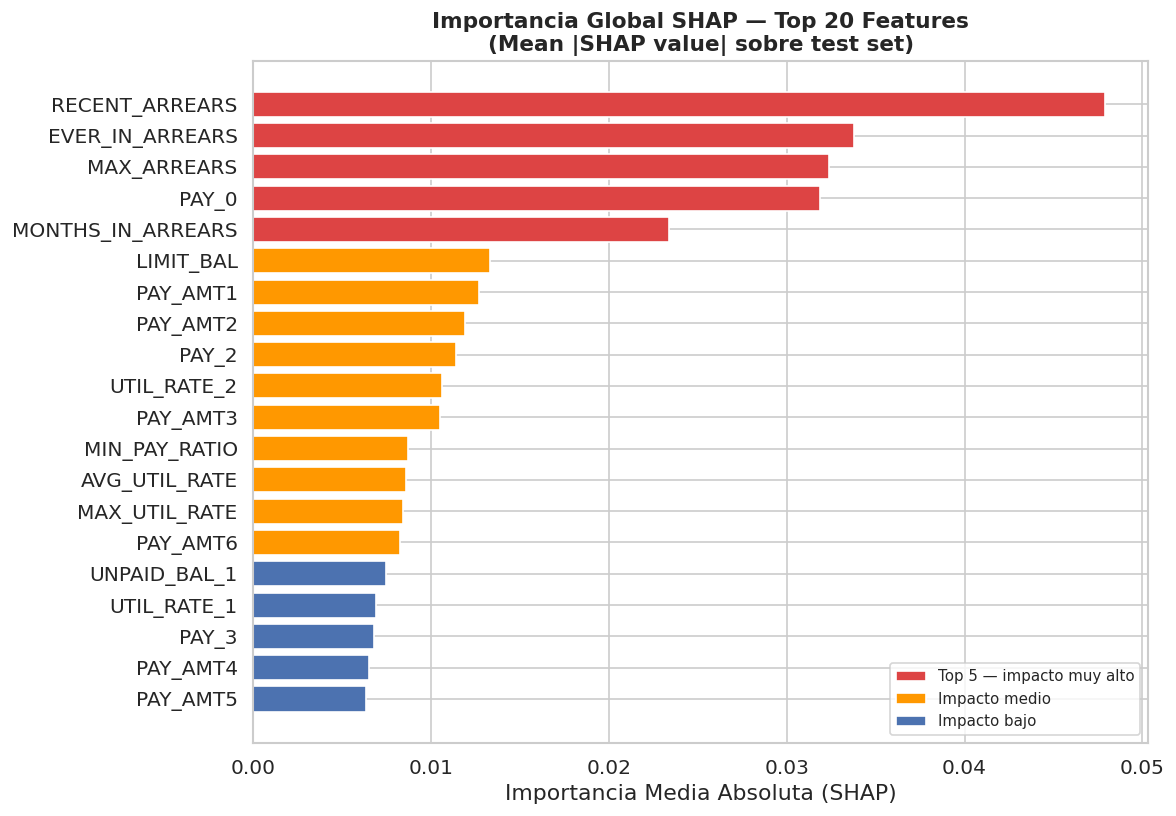


Top 10 features por importancia SHAP:
  RECENT_ARREARS            0.04792
  EVER_IN_ARREARS           0.03376
  MAX_ARREARS               0.03240
  PAY_0                     0.03186
  MONTHS_IN_ARREARS         0.02339
  LIMIT_BAL                 0.01328
  PAY_AMT1                  0.01267
  PAY_AMT2                  0.01192
  PAY_2                     0.01138
  UTIL_RATE_2               0.01060


In [4]:
# Recalcular SHAP para el gráfico de resumen
print('Calculando SHAP values...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Clase 1 (default)
sv = shap_values[:, :, 1] if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3 else shap_values[1]

# Importancia global SHAP
mean_shap = pd.Series(
    np.abs(sv).mean(axis=0),
    index=X_test.columns.tolist()
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#DD4444' if i < 5 else '#4C72B0' if i >= 15 else '#FF9800'
          for i in range(len(mean_shap))]
bars = ax.barh(mean_shap.index[::-1], mean_shap.values[::-1],
               color=colors[::-1], edgecolor='white')

legend_elements = [
    mpatches.Patch(facecolor='#DD4444', label='Top 5 — impacto muy alto'),
    mpatches.Patch(facecolor='#FF9800', label='Impacto medio'),
    mpatches.Patch(facecolor='#4C72B0', label='Impacto bajo'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_title('Importancia Global SHAP — Top 20 Features\n(Mean |SHAP value| sobre test set)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia Media Absoluta (SHAP)')
plt.tight_layout()
plt.show()

print('\nTop 10 features por importancia SHAP:')
for feat, val in mean_shap.head(10).items():
    print(f'  {feat:<25} {val:.5f}')

---
## 6. Recomendaciones de Negocio

Los hallazgos del modelo se traducen en recomendaciones concretas para la institución financiera. Están ordenadas por impacto esperado y viabilidad de implementación.

---

### Rec. 1 — Implementar scoring mensual automatizado
**Acción:** integrar el modelo en un proceso batch mensual que puntúe a toda la cartera activa y genere una lista de clientes de alto riesgo (probabilidad ≥ 0.42).

**Impacto esperado:** detección anticipada del ~66% de los clientes que van a incumplir, con un promedio de 1 a 2 meses de anticipación — tiempo suficiente para acciones de cobranza preventiva.

**Responsable sugerido:** equipo de Data Science + Operaciones de Crédito.

---

### Rec. 2 — Segmentar la cartera por nivel de riesgo
**Acción:** clasificar clientes en tres segmentos según la probabilidad de default predicha:

| Segmento | Probabilidad | Acción recomendada |
|----------|-------------|--------------------|
| 🟢 Bajo riesgo | < 0.20 | Monitoreo estándar |
| 🟡 Riesgo medio | 0.20 – 0.42 | Contacto preventivo, revisión de límite |
| 🔴 Alto riesgo | ≥ 0.42 | Acción inmediata: cobranza, reducción de límite, bloqueo preventivo |

**Impacto esperado:** concentrar los recursos de cobranza donde generan mayor retorno, reduciendo el costo operativo por cliente recuperado.

---

### Rec. 3 — Monitorear activamente el estado de pago mensual (PAY_0)
**Acción:** configurar alertas automáticas cuando `PAY_0` de un cliente pase de 0 a 1 o más — es decir, cuando entre en mora por primera vez.

**Justificación:** el análisis SHAP mostró que `PAY_0` es el feature de mayor impacto individual en las predicciones. Un cambio en este indicador es la señal más temprana y confiable de deterioro.

**Impacto esperado:** reducción del tiempo de reacción ante primeras señales de mora de semanas a días.

---

### Rec. 4 — Revisar política de límites de crédito
**Acción:** incorporar la tasa de utilización promedio (`AVG_UTIL_RATE`) como criterio en las revisiones periódicas de límite de crédito. Clientes con utilización sostenida > 80% durante 3 meses o más deberían ser evaluados para reducción o congelamiento del límite.

**Justificación:** el modelo identificó que la utilización alta es la segunda señal de riesgo más importante después del historial de pagos. Actuar sobre el límite reduce la exposición máxima antes de que ocurra el default.

---

### Rec. 5 — No usar variables demográficas como criterio de decisión
**Acción:** excluir `SEX`, `MARRIAGE` y `EDUCATION` de cualquier regla de negocio o decisión crediticia automatizada.

**Justificación:** el análisis SHAP confirmó que estas variables tienen impacto marginal en las predicciones del modelo. Su uso en decisiones crediticias introduce riesgo regulatorio y reputacional sin beneficio predictivo significativo.

---

### Rec. 6 — Establecer proceso de monitoreo y reentrenamiento del modelo
**Acción:** definir un proceso trimestral de monitoreo que mida:
- Drift en la distribución de los features (especialmente `PAY_0` y `LIMIT_BAL`).
- Degradación del ROC-AUC sobre nuevas cohortes de clientes.
- Reentrenamiento automático si el ROC-AUC cae por debajo de 0.72.

**Justificación:** el modelo fue entrenado con datos de 2005. Los patrones de comportamiento crediticio cambian con el ciclo económico. Sin monitoreo activo, el rendimiento se degrada silenciosamente.

In [5]:
# Simulación de impacto de negocio
# Supuestos conservadores para un portafolio hipotético

PORTFOLIO_SIZE     = 10_000   # clientes totales
DEFAULT_RATE       = 0.221    # tasa histórica del dataset
AVG_CREDIT_LIMIT   = 167_484  # NT$ — media del dataset
LOSS_GIVEN_DEFAULT = 0.45     # % del límite perdido en default (LGD estándar)
RECOVERY_RATE      = 0.30     # % recuperado con acción preventiva temprana

n_defaults_total   = int(PORTFOLIO_SIZE * DEFAULT_RATE)
n_detected         = int(n_defaults_total * recall_score(y_test, pred_test))
n_missed           = n_defaults_total - n_detected
n_false_alarms     = int((PORTFOLIO_SIZE - n_defaults_total) * (1 - precision_score(y_test, pred_test) / 1))

loss_without_model = n_defaults_total * AVG_CREDIT_LIMIT * LOSS_GIVEN_DEFAULT
loss_recovered     = n_detected * AVG_CREDIT_LIMIT * LOSS_GIVEN_DEFAULT * RECOVERY_RATE
loss_with_model    = loss_without_model - loss_recovered

print('=' * 55)
print('SIMULACIÓN DE IMPACTO EN PORTAFOLIO DE 10.000 CLIENTES')
print('=' * 55)
print(f'\nSupuestos:')
print(f'  Tasa de default:         {DEFAULT_RATE:.1%}')
print(f'  Límite promedio:         NT$ {AVG_CREDIT_LIMIT:,.0f}')
print(f'  Loss Given Default:      {LOSS_GIVEN_DEFAULT:.0%}')
print(f'  Recuperación preventiva: {RECOVERY_RATE:.0%}')
print(f'\nResultados del modelo:')
print(f'  Defaults totales esperados:      {n_defaults_total:,}')
print(f'  Defaults detectados por modelo:  {n_detected:,} ({n_detected/n_defaults_total:.1%})')
print(f'  Defaults no detectados:          {n_missed:,}')
print(f'\nImpacto financiero (NT$):')
print(f'  Pérdida sin modelo:              NT$ {loss_without_model:,.0f}')
print(f'  Pérdida recuperable con modelo:  NT$ {loss_recovered:,.0f}')
print(f'  Pérdida estimada con modelo:     NT$ {loss_with_model:,.0f}')
print(f'  Reducción de pérdidas:           {loss_recovered/loss_without_model:.1%}')
print('=' * 55)

SIMULACIÓN DE IMPACTO EN PORTAFOLIO DE 10.000 CLIENTES

Supuestos:
  Tasa de default:         22.1%
  Límite promedio:         NT$ 167,484
  Loss Given Default:      45%
  Recuperación preventiva: 30%

Resultados del modelo:
  Defaults totales esperados:      2,210
  Defaults detectados por modelo:  1,457 (65.9%)
  Defaults no detectados:          753

Impacto financiero (NT$):
  Pérdida sin modelo:              NT$ 166,562,838
  Pérdida recuperable con modelo:  NT$ 32,943,265
  Pérdida estimada con modelo:     NT$ 133,619,573
  Reducción de pérdidas:           19.8%


---
## 7. Limitaciones del Proyecto

Un análisis honesto de las limitaciones es tan importante como los resultados. Las siguientes limitaciones deben considerarse antes de cualquier implementación en producción.

### 7.1 Limitaciones de los datos

| Limitación | Impacto | Mitigación |
|------------|---------|------------|
| **Datos de 2005, Taiwán** | El modelo puede no generalizar a otros mercados o períodos económicos distintos | Reentrenar con datos locales y recientes antes de producción |
| **Sin variable de ingresos** | Los ingresos son el driver más directo de capacidad de pago y no están disponibles | Usar `LIMIT_BAL` y ratios de pago como proxies; incorporar ingresos si está disponible |
| **Categorías no documentadas** | `EDUCATION` y `MARRIAGE` tienen categorías sin definición oficial en el paper | Se reagruparon en "Otros"; impacto bajo dado el bajo peso de estas variables |
| **Snapshot estático** | El modelo evalúa un momento en el tiempo; no captura tendencias intra-mes | Enriquecer con features de tendencia más granulares si hay datos disponibles |

### 7.2 Limitaciones del modelo

| Limitación | Impacto | Mitigación |
|------------|---------|------------|
| **ROC-AUC de 0.779** | No alcanzó el objetivo optimista de 0.82 | Los benchmarks se calibraron a la realidad del dataset; el resultado es sólido para datos de 2005 |
| **Recall de 65.9%** | El 34.1% de los defaults no son detectados | Aceptable bajo restricción de Precisión ≥ 40%; el umbral puede ajustarse según tolerancia al riesgo |
| **Tasa de falsos positivos** | ~25% de clientes sin default son marcados como riesgosos | Costo operativo de acciones innecesarias; balancear con umbral más alto si el costo de FP es alto |
| **Sin calibración de probabilidades** | Las probabilidades predichas pueden no ser perfectamente calibradas | Aplicar Platt Scaling o Isotonic Regression en trabajo futuro |

---
## 8. Trabajo Futuro

Las siguientes líneas de trabajo permitirían mejorar el sistema en iteraciones posteriores, ordenadas por impacto esperado.

### 8.1 Mejoras de modelado

- **Stacking / Ensamble de modelos:** combinar las predicciones de Random Forest, XGBoost y LightGBM mediante un meta-modelo podría mejorar el ROC-AUC en 1-3 puntos adicionales.
- **Calibración de probabilidades:** aplicar Platt Scaling o Isotonic Regression post-entrenamiento para que las probabilidades predichas sean más confiables en aplicaciones de scoring.
- **Optimización de umbral costo-sensible:** incorporar los costos reales de FN y FP del negocio en la función de optimización del umbral, en lugar de usar F1 como proxy.

### 8.2 Mejoras de datos

- **Incorporar datos de ingresos:** la ausencia de esta variable es la brecha más importante del dataset actual.
- **Datos más recientes:** reentrenar con datos del mercado objetivo antes de producción.
- **Features de comportamiento transaccional:** número de transacciones, patrones de uso por categoría de gasto, si están disponibles.

### 8.3 Infraestructura de producción

- **API de scoring en tiempo real:** envolver el modelo en una API REST para integración con sistemas core bancarios.
- **Pipeline de monitoreo:** implementar detección de data drift (e.g., con Evidently AI) y alertas automáticas de degradación del modelo.
- **Dashboard de riesgo:** visualización en tiempo real de la distribución de scores, evolución de la tasa de default predicha y KPIs de cobranza.

---
## 9. Cierre del Módulo de Machine Learning

In [6]:
# Tabla resumen del proyecto completo
summary = {
    'Notebook': [
        '01 · Business Understanding',
        '02 · EDA',
        '03 · Preprocesamiento',
        '04 · Feature Engineering',
        '05 · Modelado',
        '06 · Conclusiones'
    ],
    'Objetivo': [
        'Definir el problema, métricas y supuestos',
        'Explorar datos, validar 8 hipótesis',
        'Limpiar, encodear y escalar el dataset',
        'Crear 14 features de comportamiento financiero',
        'Entrenar 4 modelos, optimizar y calibrar',
        'Sintetizar hallazgos y recomendar acciones'
    ],
    'Resultado clave': [
        '5 hipótesis confirmadas, 3 parciales',
        'PAY_0 y LIMIT_BAL como top predictores',
        'Dataset de 30K filas × 27 columnas limpio',
        '14 features nuevos, todos con importancia > 0',
        'RF optimizado: AUC=0.779, Recall=0.659',
        '6 recomendaciones de negocio accionables'
    ]
}

df_summary = pd.DataFrame(summary)
display(
    df_summary.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('font-weight', 'bold'), ('text-align', 'left')]
    }])
    .hide(axis='index')
)

Notebook,Objetivo,Resultado clave
01 · Business Understanding,"Definir el problema, métricas y supuestos","5 hipótesis confirmadas, 3 parciales"
02 · EDA,"Explorar datos, validar 8 hipótesis",PAY_0 y LIMIT_BAL como top predictores
03 · Preprocesamiento,"Limpiar, encodear y escalar el dataset",Dataset de 30K filas × 27 columnas limpio
04 · Feature Engineering,Crear 14 features de comportamiento financiero,"14 features nuevos, todos con importancia > 0"
05 · Modelado,"Entrenar 4 modelos, optimizar y calibrar","RF optimizado: AUC=0.779, Recall=0.659"
06 · Conclusiones,Sintetizar hallazgos y recomendar acciones,6 recomendaciones de negocio accionables


---

### Reflexión final

Este módulo demostró que es posible construir un sistema de scoring de riesgo crediticio sólido, interpretable y accionable a partir de datos históricos de comportamiento de pago — sin necesidad de variables de ingresos ni datos transaccionales complejos.

Los resultados confirman que el **comportamiento reciente de pago** es la señal más valiosa disponible para predecir default: más que cualquier variable demográfica, y más que el monto de deuda en términos absolutos. Esto tiene implicancias directas para el diseño de sistemas de alerta temprana en instituciones financieras.

El pipeline completo — desde el entendimiento del negocio hasta el modelo interpretable — está documentado, reproducible, y el modelo exportado (`model.pkl`) está listo para ser consumido por las siguientes etapas del proyecto.

---

### Próximas etapas del proyecto

| Módulo | Descripción |
|--------|-------------|
| **Backend** | API REST que expone el modelo como servicio de predicción, recibiendo datos de clientes y retornando scores de riesgo |
| **Frontend** | Interfaz de usuario para visualizar scores, segmentación de cartera y alertas de riesgo |

---

**Mathias Sebastian Huanca Pretell** · 2026

---
*Fin del módulo de Machine Learning — el proyecto continúa con Backend y Frontend*